# Project FORESIGHT
## Data Quality, Cleaning & Exploratory Data Analysis

### Objective

This notebook performs the first stage of the FORESIGHT demand and inventory
intelligence project.

The objectives are to:

- Load and inspect the four raw datasets
- Assess data quality
- Identify missing values and duplicates
- Validate data types and business constraints
- Clean and standardize the datasets
- Create an analysis-ready dataset
- Explore demand, sales, promotions, seasonality and inventory
- Identify initial business insights for forecasting and inventory risk

### Source Tables

1. `sales_daily.csv`
2. `sku_master.csv`
3. `calendar.csv`
4. `inventory_snapshots.csv`

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [2]:
ROOT_DIR = Path.cwd().parent

RAW_DIR = ROOT_DIR / "data" / "raw"
PROCESSED_DIR = ROOT_DIR / "data" / "processed"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT_DIR)
print("Raw data:", RAW_DIR)
print("Processed data:", PROCESSED_DIR)

Project root: c:\Users\saqib\Desktop\zidio\foresight-demand-inventory
Raw data: c:\Users\saqib\Desktop\zidio\foresight-demand-inventory\data\raw
Processed data: c:\Users\saqib\Desktop\zidio\foresight-demand-inventory\data\processed


## Loading the Raw Data

The project uses four separate raw extracts representing:

- Daily sales transactions
- SKU/product metadata
- Calendar and promotional information
- Inventory snapshots

In [3]:
sales = pd.read_csv(RAW_DIR / "sales_daily.csv")
sku_master = pd.read_csv(RAW_DIR / "sku_master.csv")
calendar = pd.read_csv(RAW_DIR / "calendar.csv")
inventory = pd.read_csv(RAW_DIR / "inventory_snapshots.csv")

In [4]:
datasets = {
    "Sales": sales,
    "SKU Master": sku_master,
    "Calendar": calendar,
    "Inventory": inventory
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

Sales: (125212, 6)
SKU Master: (200, 6)
Calendar: (1096, 6)
Inventory: (31400, 6)


In [5]:
sales.head()

,date,sku_id,units_sold,revenue,unit_price,promo_flag
0,2024-08-12,SKU_0001,6,"89,863.74","14,977.29",0
1,2024-08-13,SKU_0001,1,"14,977.29","14,977.29",0
2,2024-08-14,SKU_0001,4,"59,909.16","14,977.29",0
3,2024-08-15,SKU_0001,0,0.00,"14,977.29",0
4,2024-08-16,SKU_0001,1,"14,977.29","14,977.29",0


In [6]:
sku_master.head()

,sku_id,category,subcategory,launch_date,unit_cost,list_price
0,SKU_0001,Furniture,Desk,2024-08-12,"6,911.20","14,977.29"
1,SKU_0002,Decor,Lamp,2023-03-26,"7,812.29","17,478.07"
2,SKU_0003,Kitchen,Utensil,2024-04-06,"3,767.97","6,812.03"
3,SKU_0004,Furniture,Chair,2025-04-14,"5,257.76","12,119.34"
4,SKU_0005,Kitchen,Appliance,2024-02-10,"4,570.30","6,719.25"


In [7]:
calendar.head()

,date,week,month,season,is_holiday,promo_event
0,2023-01-01,52,1,Winter,1,NaN
1,2023-01-02,1,1,Winter,0,NaN
2,2023-01-03,1,1,Winter,0,NaN
3,2023-01-04,1,1,Winter,0,NaN
4,2023-01-05,1,1,Winter,0,NaN


In [8]:
inventory.head()

,date,sku_id,on_hand_units,on_order_units,lead_time_days,reorder_point
0,2023-01-01,SKU_0001,64,0,5,17
1,2023-01-08,SKU_0001,45,0,5,17
2,2023-01-15,SKU_0001,30,0,5,17
3,2023-01-22,SKU_0001,0,36,5,17
4,2023-01-29,SKU_0001,36,0,5,17


## Schema and Data-Type Inspection

We inspect column names and data types before performing any cleaning.
This helps identify fields requiring date conversion, numeric conversion,
or categorical standardization.

In [9]:
for name, df in datasets.items():
    print("=" * 60)
    print(name)
    print("=" * 60)
    print(df.info())
    print()

Sales
<class 'pandas.DataFrame'>
RangeIndex: 125212 entries, 0 to 125211
Data columns (total 6 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   date        125212 non-null  str    
 1   sku_id      125212 non-null  str    
 2   units_sold  125212 non-null  int64  
 3   revenue     125212 non-null  float64
 4   unit_price  125149 non-null  float64
 5   promo_flag  125212 non-null  int64  
dtypes: float64(2), int64(2), str(2)
memory usage: 7.9 MB
None

SKU Master
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sku_id       200 non-null    str    
 1   category     200 non-null    str    
 2   subcategory  200 non-null    str    
 3   launch_date  200 non-null    str    
 4   unit_cost    200 non-null    float64
 5   list_price   200 non-null    float64
dtypes: float64(2), str(4)
memory usage: 15.7 KB
None



In [10]:
sales["date"] = pd.to_datetime(sales["date"])
sku_master["launch_date"] = pd.to_datetime(sku_master["launch_date"])
calendar["date"] = pd.to_datetime(calendar["date"])
inventory["date"] = pd.to_datetime(inventory["date"])

In [11]:
print(sales["date"].dtype)
print(sku_master["launch_date"].dtype)
print(calendar["date"].dtype)
print(inventory["date"].dtype)

datetime64[us]
datetime64[us]
datetime64[us]
datetime64[us]


## Data Quality Assessment

The raw datasets are checked for:

- Missing values
- Duplicate records
- Invalid numeric values
- Invalid dates
- Negative sales
- Negative revenue
- Invalid prices
- Invalid inventory quantities
- Inconsistent categorical labels

In [12]:
def missing_report(df):
    report = pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_percent": df.isna().mean() * 100
    })

    return report.sort_values(
        "missing_count",
        ascending=False
    )

print("SALES")
display(missing_report(sales))

print("SKU MASTER")
display(missing_report(sku_master))

print("CALENDAR")
display(missing_report(calendar))

print("INVENTORY")
display(missing_report(inventory))

SALES


,missing_count,missing_percent
unit_price,63,0.05
date,0,0.00
sku_id,0,0.00
units_sold,0,0.00
revenue,0,0.00
promo_flag,0,0.00


SKU MASTER


,missing_count,missing_percent
sku_id,0,0.00
category,0,0.00
subcategory,0,0.00
launch_date,0,0.00
unit_cost,0,0.00
list_price,0,0.00


CALENDAR


,missing_count,missing_percent
promo_event,928,84.67
date,0,0.00
week,0,0.00
month,0,0.00
season,0,0.00
is_holiday,0,0.00


INVENTORY


,missing_count,missing_percent
date,0,0.00
sku_id,0,0.00
on_hand_units,0,0.00
on_order_units,0,0.00
lead_time_days,0,0.00
reorder_point,0,0.00


In [13]:
print("Sales duplicate rows:", sales.duplicated().sum())
print("SKU duplicate rows:", sku_master.duplicated().sum())
print("Calendar duplicate rows:", calendar.duplicated().sum())
print("Inventory duplicate rows:", inventory.duplicated().sum())

Sales duplicate rows: 125
SKU duplicate rows: 0
Calendar duplicate rows: 0
Inventory duplicate rows: 0


In [14]:
print("Unique SKUs:", sku_master["sku_id"].nunique())
print("Sales SKUs:", sales["sku_id"].nunique())
print("Inventory SKUs:", inventory["sku_id"].nunique())

Unique SKUs: 200
Sales SKUs: 200
Inventory SKUs: 200


In [15]:
print(
    "Duplicate SKU IDs in master:",
    sku_master["sku_id"].duplicated().sum()
)

print(
    "Duplicate calendar dates:",
    calendar["date"].duplicated().sum()
)

print(
    "Duplicate inventory date-SKU combinations:",
    inventory.duplicated(["date", "sku_id"]).sum()
)

Duplicate SKU IDs in master: 0
Duplicate calendar dates: 0
Duplicate inventory date-SKU combinations: 0


In [16]:
print("Negative units sold:", (sales["units_sold"] < 0).sum())
print("Negative revenue:", (sales["revenue"] < 0).sum())
print("Negative unit price:", (sales["unit_price"] < 0).sum())

print("Negative inventory:", (inventory["on_hand_units"] < 0).sum())
print("Negative on-order:", (inventory["on_order_units"] < 0).sum())

Negative units sold: 0
Negative revenue: 0
Negative unit price: 0
Negative inventory: 0
Negative on-order: 0


In [17]:
sales.describe()

,date,units_sold,revenue,unit_price,promo_flag
count,125212,"125,212.00","125,212.00","125,149.00","125,212.00"
mean,2025-01-04 14:57:23.018241,14.85,"127,460.76","8,408.16",0.17
min,2023-01-05 00:00:00,0.00,0.00,400.40,0.00
25%,2024-07-19 00:00:00,5.00,"25,252.82","4,044.61",0.00
50%,2025-02-16 00:00:00,11.00,"70,707.57","8,157.36",0.00
75%,2025-07-28 00:00:00,20.00,"163,507.41","12,034.20",0.00
max,2025-12-31 00:00:00,289.00,"2,224,994.24","18,906.98",1.00
std,NaN,14.71,"165,125.05","4,962.59",0.37


In [18]:
inventory.describe()

,date,on_hand_units,on_order_units,lead_time_days,reorder_point
count,31400,"31,400.00","31,400.00","31,400.00","31,400.00"
mean,2024-06-30 00:00:00,165.49,128.26,8.34,145.42
min,2023-01-01 00:00:00,0.00,0.00,3.00,11.00
25%,2023-10-01 00:00:00,38.00,0.00,5.00,50.50
50%,2024-06-30 00:00:00,104.00,0.00,8.00,115.50
75%,2025-03-30 00:00:00,227.00,202.00,11.00,198.50
max,2025-12-28 00:00:00,"2,356.00","2,356.00",14.00,730.00
std,NaN,192.67,203.85,3.46,122.75


In [19]:
sku_master.describe()

,launch_date,unit_cost,list_price
count,200,200.00,200.00
mean,2024-04-15 13:33:36,"4,122.65","8,194.13"
min,2023-01-05 00:00:00,334.65,497.96
25%,2023-09-29 18:00:00,"2,045.20","3,607.27"
50%,2024-04-13 12:00:00,"4,203.07","7,948.27"
75%,2024-11-26 06:00:00,"6,141.68","11,928.54"
max,2025-06-10 00:00:00,"7,990.32","18,906.98"
std,NaN,"2,319.38","4,982.69"


## Sales Data Cleaning

Cleaning actions:

1. Remove duplicate records
2. Convert date fields
3. Validate numeric fields
4. Handle missing unit prices
5. Recalculate revenue where appropriate

In [20]:
sales = sales.drop_duplicates().copy()

In [21]:
print("Remaining duplicate rows:", sales.duplicated().sum())

Remaining duplicate rows: 0


In [22]:
missing_price = sales["unit_price"].isna().sum()

print("Missing unit prices before cleaning:", missing_price)

Missing unit prices before cleaning: 63


In [23]:
sales = sales.merge(
    sku_master[["sku_id", "list_price"]],
    on="sku_id",
    how="left"
)

In [24]:
sales["unit_price"] = sales["unit_price"].fillna(
    sales["list_price"]
)

In [25]:
sales.drop(columns=["list_price"], inplace=True)

In [26]:
sales["revenue"] = (
    sales["units_sold"] * sales["unit_price"]
).round(2)

In [27]:
sku_master["category"] = (
    sku_master["category"]
    .astype(str)
    .str.strip()
    .str.title()
)

sku_master["subcategory"] = (
    sku_master["subcategory"]
    .astype(str)
    .str.strip()
)

In [28]:
sku_master["category"].value_counts()

category
Kitchen      66
Decor        51
Lighting     42
Furniture    41
Name: count, dtype: int64

In [29]:
calendar["promo_event"] = (
    calendar["promo_event"]
    .fillna("No Promotion")
    .astype(str)
    .str.strip()
)

calendar["season"] = (
    calendar["season"]
    .astype(str)
    .str.strip()
)

In [30]:
inventory = inventory.drop_duplicates(
    subset=["date", "sku_id"]
).copy()

inventory["on_hand_units"] = inventory["on_hand_units"].clip(lower=0)
inventory["on_order_units"] = inventory["on_order_units"].clip(lower=0)
inventory["lead_time_days"] = inventory["lead_time_days"].clip(lower=0)
inventory["reorder_point"] = inventory["reorder_point"].clip(lower=0)

## Post-Cleaning Validation

After cleaning, we repeat the major quality checks to confirm that the
data is suitable for downstream analysis.

In [31]:
print("Sales duplicates:", sales.duplicated().sum())
print("SKU duplicates:", sku_master.duplicated().sum())
print("Calendar duplicates:", calendar.duplicated().sum())
print("Inventory duplicates:", inventory.duplicated(["date", "sku_id"]).sum())

Sales duplicates: 0
SKU duplicates: 0
Calendar duplicates: 0
Inventory duplicates: 0


In [32]:
print("Missing sales values:")
display(missing_report(sales))

print("Missing SKU values:")
display(missing_report(sku_master))

print("Missing calendar values:")
display(missing_report(calendar))

print("Missing inventory values:")
display(missing_report(inventory))

Missing sales values:


,missing_count,missing_percent
date,0,0.00
sku_id,0,0.00
units_sold,0,0.00
revenue,0,0.00
unit_price,0,0.00
promo_flag,0,0.00


Missing SKU values:


,missing_count,missing_percent
sku_id,0,0.00
category,0,0.00
subcategory,0,0.00
launch_date,0,0.00
unit_cost,0,0.00
list_price,0,0.00


Missing calendar values:


,missing_count,missing_percent
date,0,0.00
week,0,0.00
month,0,0.00
season,0,0.00
is_holiday,0,0.00
promo_event,0,0.00


Missing inventory values:


,missing_count,missing_percent
date,0,0.00
sku_id,0,0.00
on_hand_units,0,0.00
on_order_units,0,0.00
lead_time_days,0,0.00
reorder_point,0,0.00


# Creating the Analysis Dataset

We combine:

- Sales transactions
- SKU attributes
- Calendar information

This creates a daily SKU-level analytical dataset containing demand,
price, promotion, holiday, season and product information.

In [33]:
analysis_daily = sales.merge(
    sku_master,
    on="sku_id",
    how="left"
)

analysis_daily = analysis_daily.merge(
    calendar,
    on="date",
    how="left"
)

In [34]:
analysis_daily.shape

(125087, 16)

In [35]:
print(
    "Missing category after merge:",
    analysis_daily["category"].isna().sum()
)

print(
    "Missing season after merge:",
    analysis_daily["season"].isna().sum()
)

print(
    "Missing calendar rows:",
    analysis_daily["week"].isna().sum()
)

Missing category after merge: 0
Missing season after merge: 0
Missing calendar rows: 0


In [36]:
analysis_daily["year"] = analysis_daily["date"].dt.year
analysis_daily["quarter"] = analysis_daily["date"].dt.quarter
analysis_daily["month"] = analysis_daily["date"].dt.month
analysis_daily["day_of_week"] = analysis_daily["date"].dt.dayofweek
analysis_daily["day_name"] = analysis_daily["date"].dt.day_name()

In [37]:
total_units = analysis_daily["units_sold"].sum()
total_revenue = analysis_daily["revenue"].sum()

print(f"Total units sold: {total_units:,.0f}")
print(f"Total revenue: ₹{total_revenue:,.2f}")
print(f"Active SKUs: {analysis_daily['sku_id'].nunique():,}")

Total units sold: 1,857,449
Total revenue: ₹15,943,775,271.68
Active SKUs: 200


# Exploratory Data Analysis

## 1. Overall Demand Trend

We first examine how total daily demand changes over time.

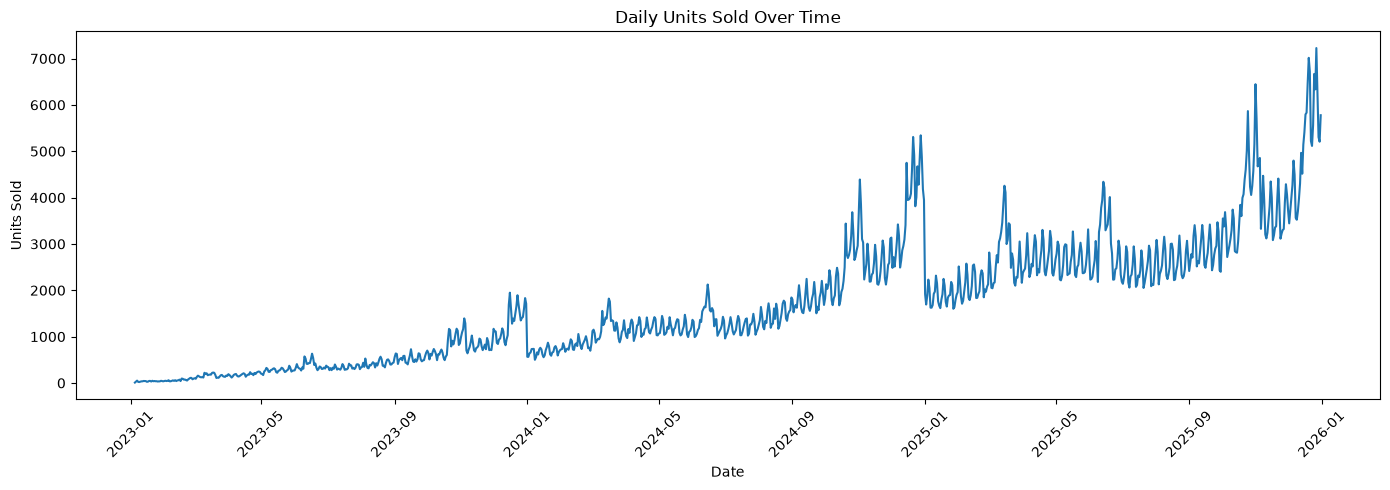

In [38]:
daily_sales = (
    analysis_daily
    .groupby("date", as_index=False)["units_sold"]
    .sum()
)

plt.figure(figsize=(14, 5))

plt.plot(
    daily_sales["date"],
    daily_sales["units_sold"]
)

plt.title("Daily Units Sold Over Time")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

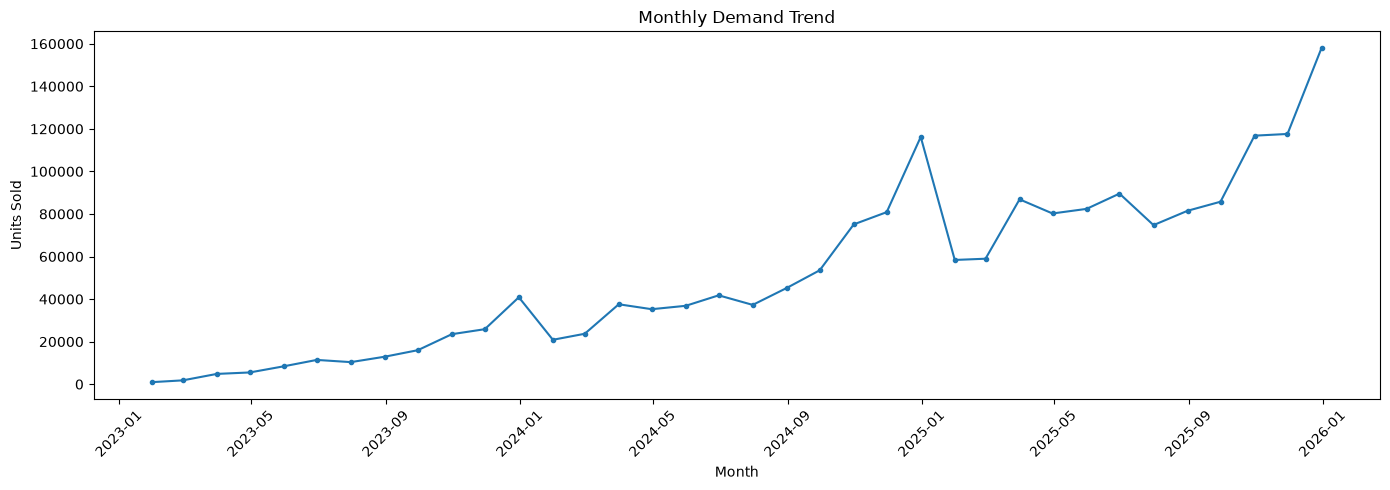

In [39]:
monthly_sales = (
    analysis_daily
    .set_index("date")
    .resample("ME")["units_sold"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 5))

plt.plot(
    monthly_sales["date"],
    monthly_sales["units_sold"],
    marker="o",
    markersize=3
)

plt.title("Monthly Demand Trend")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

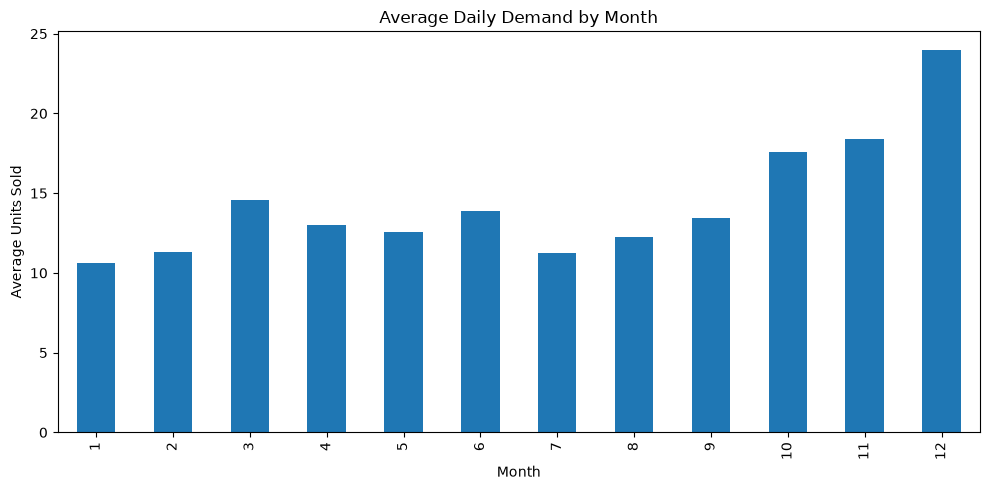

In [40]:
month_demand = (
    analysis_daily
    .groupby("month")["units_sold"]
    .mean()
)

plt.figure(figsize=(10, 5))

month_demand.plot(kind="bar")

plt.title("Average Daily Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Units Sold")
plt.tight_layout()
plt.show()

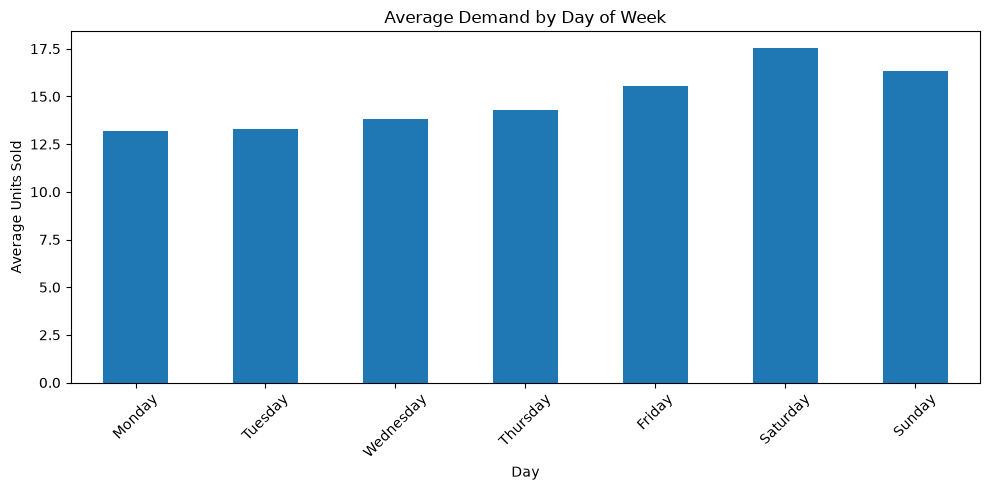

In [41]:
weekday_demand = (
    analysis_daily
    .groupby("day_name")["units_sold"]
    .mean()
)

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_demand = weekday_demand.reindex(day_order)

plt.figure(figsize=(10, 5))

weekday_demand.plot(kind="bar")

plt.title("Average Demand by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [42]:
top_skus = (
    analysis_daily
    .groupby("sku_id")["units_sold"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_skus

sku_id
SKU_0045    49186
SKU_0098    43578
SKU_0048    42767
SKU_0023    39319
SKU_0171    34644
SKU_0181    30662
SKU_0089    29317
SKU_0029    27664
SKU_0067    26680
SKU_0103    24740
Name: units_sold, dtype: int64

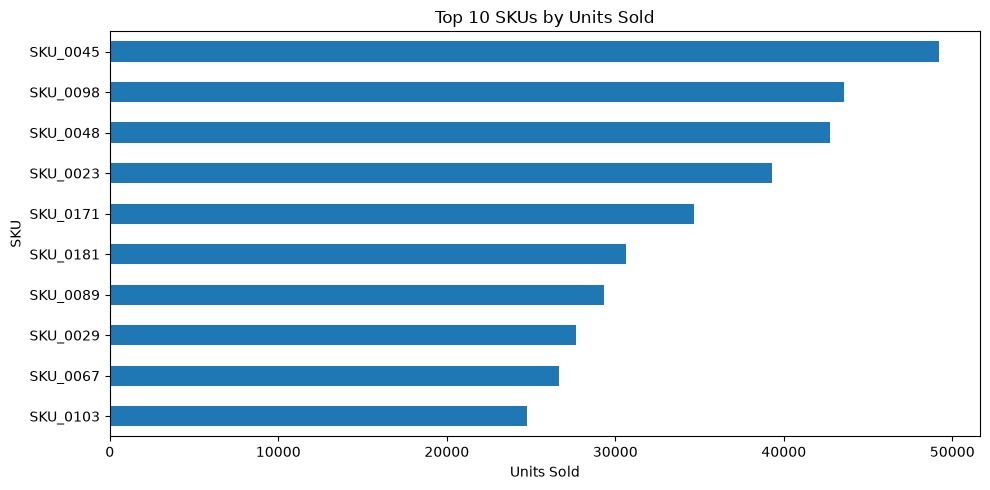

In [43]:
plt.figure(figsize=(10, 5))

top_skus.sort_values().plot(kind="barh")

plt.title("Top 10 SKUs by Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("SKU")
plt.tight_layout()
plt.show()

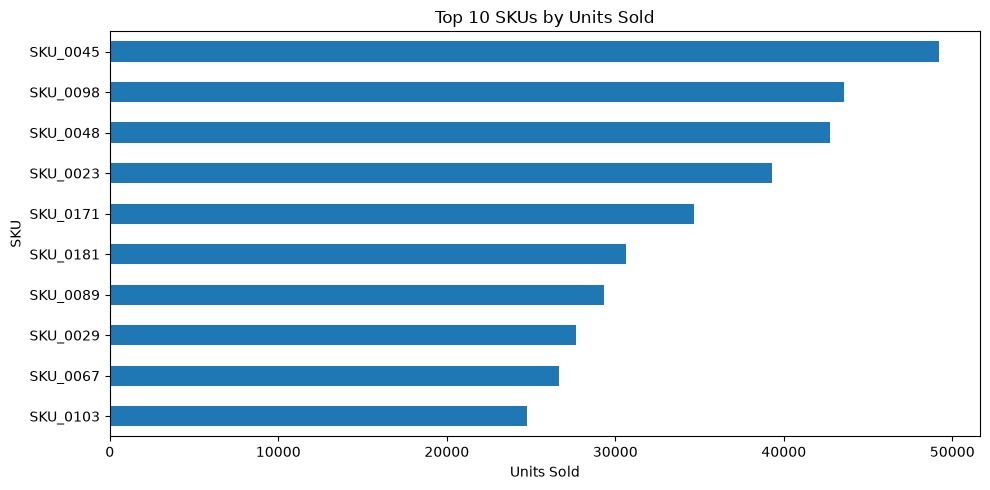

In [44]:
plt.figure(figsize=(10, 5))

top_skus.sort_values().plot(kind="barh")

plt.title("Top 10 SKUs by Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("SKU")
plt.tight_layout()
plt.show()

In [45]:
category_revenue = (
    analysis_daily
    .groupby("category")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

category_revenue

category
Kitchen     5,248,849,287.77
Decor       5,244,051,456.75
Furniture   2,761,100,104.21
Lighting    2,689,774,422.95
Name: revenue, dtype: float64

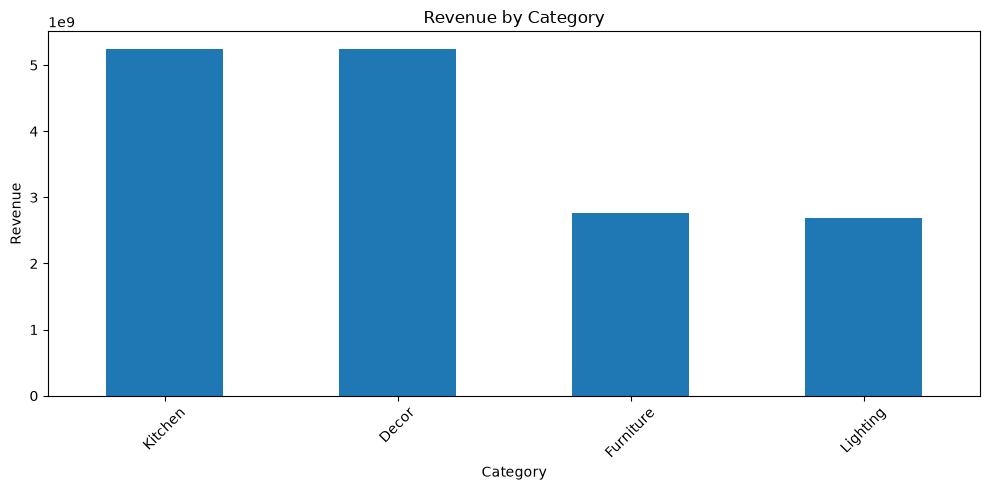

In [46]:
plt.figure(figsize=(10, 5))

category_revenue.plot(kind="bar")

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [47]:
category_demand = (
    analysis_daily
    .groupby("category")["units_sold"]
    .sum()
    .sort_values(ascending=False)
)

category_demand

category
Kitchen      603913
Decor        580362
Lighting     337192
Furniture    335982
Name: units_sold, dtype: int64

## Promotion Impact

We compare average demand on promotional versus non-promotional days.

In [48]:
promo_demand = (
    analysis_daily
    .groupby("promo_flag")["units_sold"]
    .mean()
)

promo_demand.index = [
    "Non-Promotion",
    "Promotion"
]

promo_demand

Non-Promotion   13.26
Promotion       22.76
Name: units_sold, dtype: float64

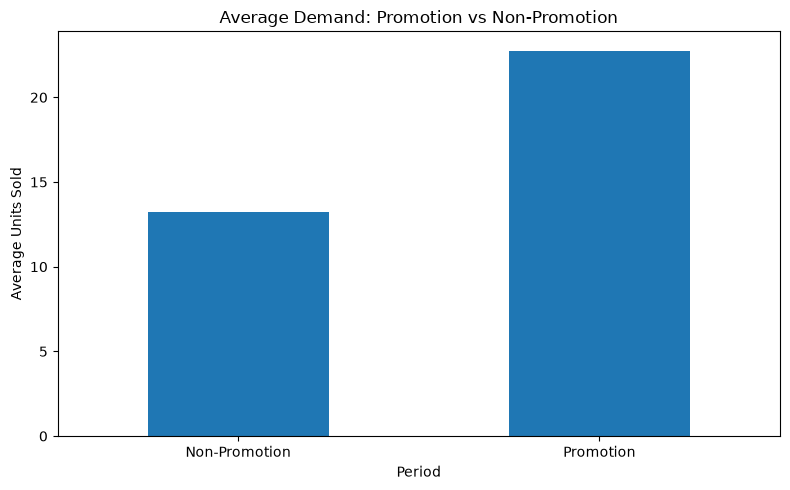

In [49]:
plt.figure(figsize=(8, 5))

promo_demand.plot(kind="bar")

plt.title("Average Demand: Promotion vs Non-Promotion")
plt.xlabel("Period")
plt.ylabel("Average Units Sold")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [50]:
holiday_demand = (
    analysis_daily
    .groupby("is_holiday")["units_sold"]
    .mean()
)

holiday_demand.index = [
    "Non-Holiday",
    "Holiday"
]

holiday_demand

Non-Holiday   14.81
Holiday       17.95
Name: units_sold, dtype: float64

# Inventory Analysis

We now examine inventory levels and identify SKUs that may require
replenishment attention.

In [51]:
inventory["inventory_status"] = np.select(
    [
        inventory["on_hand_units"] == 0,
        inventory["on_hand_units"] <= inventory["reorder_point"],
        inventory["on_hand_units"] > inventory["reorder_point"] * 3
    ],
    [
        "Stockout",
        "Reorder",
        "High Inventory"
    ],
    default="Healthy"
)

inventory["inventory_status"].value_counts()

inventory_status
Healthy           13478
Reorder           13143
High Inventory     2685
Stockout           2094
Name: count, dtype: int64

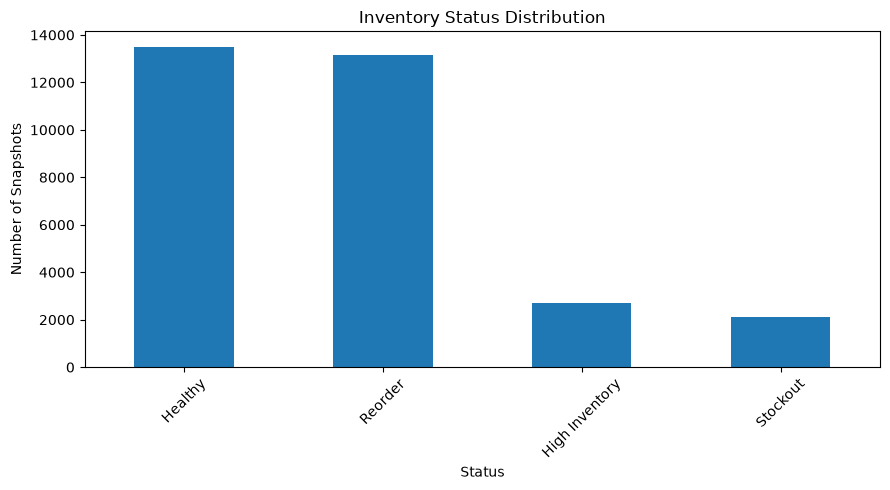

In [52]:
inventory_status = inventory["inventory_status"].value_counts()

plt.figure(figsize=(9, 5))

inventory_status.plot(kind="bar")

plt.title("Inventory Status Distribution")
plt.xlabel("Status")
plt.ylabel("Number of Snapshots")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [53]:
stockout_rate = (
    inventory
    .groupby("sku_id")
    .apply(
        lambda x: (x["on_hand_units"] == 0).mean(),
        include_groups=False
    )
    .sort_values(ascending=False)
)

stockout_rate.head(10)

sku_id
SKU_0099   0.21
SKU_0124   0.21
SKU_0098   0.21
SKU_0075   0.20
SKU_0077   0.20
SKU_0007   0.19
SKU_0017   0.19
SKU_0021   0.19
SKU_0149   0.18
SKU_0174   0.18
dtype: float64

In [54]:
high_inventory = (
    inventory
    .groupby("sku_id")["on_hand_units"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

high_inventory

sku_id
SKU_0045   1,076.35
SKU_0048     631.52
SKU_0052     606.52
SKU_0139     591.75
SKU_0181     575.57
SKU_0120     514.82
SKU_0023     445.70
SKU_0103     445.35
SKU_0034     413.74
SKU_0135     413.50
Name: on_hand_units, dtype: float64

In [55]:
sku_demand_stats = (
    analysis_daily
    .groupby("sku_id")["units_sold"]
    .agg(
        mean_demand="mean",
        std_demand="std",
        total_demand="sum"
    )
)

sku_demand_stats["coefficient_of_variation"] = (
    sku_demand_stats["std_demand"]
    / sku_demand_stats["mean_demand"].replace(0, np.nan)
)

sku_demand_stats.sort_values(
    "coefficient_of_variation",
    ascending=False
).head(10)

,mean_demand,std_demand,total_demand,coefficient_of_variation
sku_id,,,,
SKU_0046,1.11,1.11,489,1.01
SKU_0170,1.27,1.24,1039,0.98
SKU_0073,1.82,1.53,1124,0.84
SKU_0009,1.87,1.52,797,0.81
SKU_0158,1.88,1.52,1264,0.81
SKU_0152,2.22,1.78,1813,0.80
SKU_0075,1.80,1.43,1391,0.79
SKU_0003,2.43,1.91,1546,0.78
SKU_0077,2.23,1.72,1284,0.77


In [56]:
sku_volume = (
    analysis_daily
    .groupby("sku_id")["units_sold"]
    .sum()
    .sort_values(ascending=False)
)

sku_volume_df = sku_volume.to_frame("total_units")

sku_volume_df["cumulative_share"] = (
    sku_volume_df["total_units"].cumsum()
    / sku_volume_df["total_units"].sum()
)

sku_volume_df["abc_class"] = np.select(
    [
        sku_volume_df["cumulative_share"] <= 0.80,
        sku_volume_df["cumulative_share"] <= 0.95
    ],
    [
        "A",
        "B"
    ],
    default="C"
)

sku_volume_df.head(20)

,total_units,cumulative_share,abc_class
sku_id,,,
SKU_0045,49186,0.03,A
SKU_0098,43578,0.05,A
SKU_0048,42767,0.07,A
SKU_0023,39319,0.09,A
SKU_0171,34644,0.11,A
SKU_0181,30662,0.13,A
SKU_0089,29317,0.15,A
SKU_0029,27664,0.16,A
SKU_0067,26680,0.17,A


# Weekly Forecasting Dataset

The forecasting stage will work at a weekly SKU level to reduce daily noise
and provide a practical planning horizon.

In [57]:
analysis_daily["week_start"] = (
    analysis_daily["date"]
    - pd.to_timedelta(
        analysis_daily["date"].dt.dayofweek,
        unit="D"
    )
)

In [58]:
analysis_daily["week_start"] = (
    analysis_daily["date"]
    - pd.to_timedelta(
        analysis_daily["date"].dt.dayofweek,
        unit="D"
    )
)

In [59]:
weekly_sales = (
    analysis_daily
    .groupby(
        ["week_start", "sku_id"],
        as_index=False
    )
    .agg(
        units_sold=("units_sold", "sum"),
        revenue=("revenue", "sum"),
        avg_price=("unit_price", "mean"),
        promo_days=("promo_flag", "sum"),
        holiday_days=("is_holiday", "sum")
    )
)

weekly_sales.head()

,week_start,sku_id,units_sold,revenue,avg_price,promo_days,holiday_days
0,2023-01-02,SKU_0055,14,"46,322.08","3,308.72",0,0
1,2023-01-02,SKU_0067,63,"747,406.17","11,863.59",0,0
2,2023-01-02,SKU_0111,37,"431,697.87","11,667.51",0,0
3,2023-01-09,SKU_0055,21,"69,483.12","3,308.72",0,0
4,2023-01-09,SKU_0067,104,"1,233,813.36","11,863.59",0,0


In [60]:
weekly_sales = weekly_sales.merge(
    sku_master,
    on="sku_id",
    how="left"
)

In [61]:
inventory["week_start"] = (
    inventory["date"]
    - pd.to_timedelta(
        inventory["date"].dt.dayofweek,
        unit="D"
    )
)

In [62]:
weekly_inventory = (
    inventory
    .groupby(
        ["week_start", "sku_id"],
        as_index=False
    )
    .agg(
        on_hand_units=("on_hand_units", "last"),
        on_order_units=("on_order_units", "last"),
        lead_time_days=("lead_time_days", "last"),
        reorder_point=("reorder_point", "last")
    )
)

In [63]:
analysis_ready = weekly_sales.merge(
    weekly_inventory,
    on=["week_start", "sku_id"],
    how="left"
)

In [64]:
analysis_ready.shape

(18072, 16)

In [65]:
analysis_ready.head()

,week_start,sku_id,units_sold,revenue,avg_price,promo_days,holiday_days,category,subcategory,launch_date,unit_cost,list_price,on_hand_units,on_order_units,lead_time_days,reorder_point
0,2023-01-02,SKU_0055,14,"46,322.08","3,308.72",0,0,Decor,Rug,2023-01-05,"2,155.47","3,308.72",0.00,124.00,7.00,44.00
1,2023-01-02,SKU_0067,63,"747,406.17","11,863.59",0,0,Kitchen,Appliance,2023-01-06,"4,889.53","11,863.59",211.00,0.00,4.00,118.00
2,2023-01-02,SKU_0111,37,"431,697.87","11,667.51",0,0,Kitchen,Utensil,2023-01-05,"7,624.20","11,667.51",194.00,0.00,4.00,63.00
3,2023-01-09,SKU_0055,21,"69,483.12","3,308.72",0,0,Decor,Rug,2023-01-05,"2,155.47","3,308.72",124.00,0.00,7.00,44.00
4,2023-01-09,SKU_0067,104,"1,233,813.36","11,863.59",0,0,Kitchen,Appliance,2023-01-06,"4,889.53","11,863.59",60.00,494.00,4.00,118.00


In [66]:
analysis_ready.isna().sum().sort_values(
    ascending=False
).head(20)

on_hand_units     200
on_order_units    200
lead_time_days    200
reorder_point     200
week_start          0
sku_id              0
units_sold          0
revenue             0
category            0
holiday_days        0
promo_days          0
avg_price           0
list_price          0
unit_cost           0
launch_date         0
subcategory         0
dtype: int64

In [67]:
analysis_ready.describe(include="all")

,week_start,sku_id,units_sold,revenue,avg_price,promo_days,holiday_days,category,subcategory,launch_date,unit_cost,list_price,on_hand_units,on_order_units,lead_time_days,reorder_point
count,18072,18072,"18,072.00","18,072.00","18,072.00","18,072.00","18,072.00",18072,18072,18072,"18,072.00","18,072.00","17,872.00","17,872.00","17,872.00","17,872.00"
unique,NaN,200,NaN,NaN,NaN,NaN,NaN,4,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,SKU_0055,NaN,NaN,NaN,NaN,NaN,Kitchen,Appliance,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,157,NaN,NaN,NaN,NaN,NaN,5564,1821,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2025-01-02 14:56:15.298804,NaN,102.78,"882,236.35","8,395.55",1.16,0.09,NaN,NaN,2024-01-11 08:31:04.541832,"4,324.69","8,581.67",158.48,123.16,8.17,139.14
min,2023-01-02 00:00:00,NaN,0.00,0.00,425.08,0.00,0.00,NaN,NaN,2023-01-05 00:00:00,334.65,497.96,0.00,0.00,3.00,11.00
25%,2024-07-15 00:00:00,NaN,40.00,"203,652.40","4,044.61",0.00,0.00,NaN,NaN,2023-06-05 00:00:00,"2,155.47","4,157.18",36.00,0.00,5.00,47.00
50%,2025-02-17 00:00:00,NaN,78.00,"508,859.76","8,200.49",0.00,0.00,NaN,NaN,2024-01-10 00:00:00,"4,558.05","8,667.41",100.00,0.00,8.00,108.00
75%,2025-07-28 00:00:00,NaN,137.00,"1,149,533.88","11,957.45",0.00,0.00,NaN,NaN,2024-07-26 00:00:00,"6,471.41","12,174.47",217.00,191.00,11.00,196.00
max,2025-12-29 00:00:00,NaN,"1,342.00","10,855,948.45","18,906.98",7.00,1.00,NaN,NaN,2025-06-10 00:00:00,"7,990.32","18,906.98","2,356.00","2,356.00",14.00,730.00


# Save Analysis-Ready Dataset

The cleaned weekly SKU-level dataset is saved to the processed data directory
for use by the forecasting and risk-scoring stages.

In [68]:
output_path = (
    PROCESSED_DIR
    / "analysis_ready_weekly.csv"
)

analysis_ready.to_csv(
    output_path,
    index=False
)

print("Saved:", output_path)
print("Shape:", analysis_ready.shape)

Saved: c:\Users\saqib\Desktop\zidio\foresight-demand-inventory\data\processed\analysis_ready_weekly.csv
Shape: (18072, 16)


# Key Business Insights

### Demand

- Demand varies substantially across SKUs.
- A relatively small group of SKUs accounts for a large share of total volume.
- Weekly and monthly seasonality should be considered in forecasting.

### Promotions

- Promotional periods can materially change demand.
- Promotion flags should therefore be included as forecasting features.

### Inventory

- Inventory snapshots show a mixture of healthy, low-stock and stockout conditions.
- Reorder-point breaches can be used as an early warning signal.
- High inventory relative to demand can indicate potential overstock risk.

### Forecasting Implications

The EDA suggests that a useful forecasting solution should consider:

- Historical demand
- Weekly seasonality
- Annual/seasonal patterns
- Promotions
- SKU-level differences
- Demand variability

# Conclusion

The raw sales, SKU, calendar and inventory datasets were successfully
loaded, inspected and cleaned.

The data-quality process addressed:

- Duplicate records
- Missing values
- Data-type consistency
- Categorical consistency
- Invalid inventory/sales values

The datasets were then combined into a weekly SKU-level analysis dataset.

The EDA identified important demand and inventory characteristics including:

- Demand variability between SKUs
- Weekly and monthly seasonality
- Promotional demand effects
- Revenue concentration
- Inventory and stockout patterns

The resulting analysis-ready dataset will be used in the next stage:

**02_baseline.ipynb**

where we will establish the seasonal-naive forecasting baseline and
evaluate it using WAPE.